Kent Lin Chan

20202132

Se usó python 3.14.2

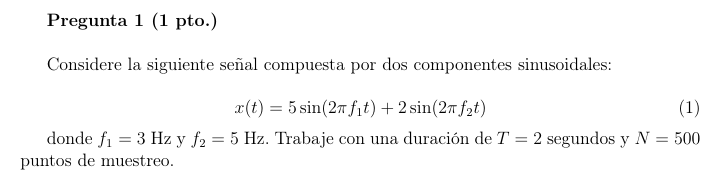

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from math import *

In [83]:
f1 = 3  # Hz
f2 = 5  # Hz
T = 2   # segundos
N = 500 # puntos de muestreo

Fs_min = 2 * max(f1, f2)
print(f"Frecuencia maxima de senal: {max(f1, f2)} Hz")
print(f"Frecuencia de muestreo minima (Nyquist): {Fs_min} Hz")

Frecuencia maxima de senal: 5 Hz
Frecuencia de muestreo minima (Nyquist): 10 Hz


a) Implemente la señal x(t) y grafíquela en el dominio del tiempo

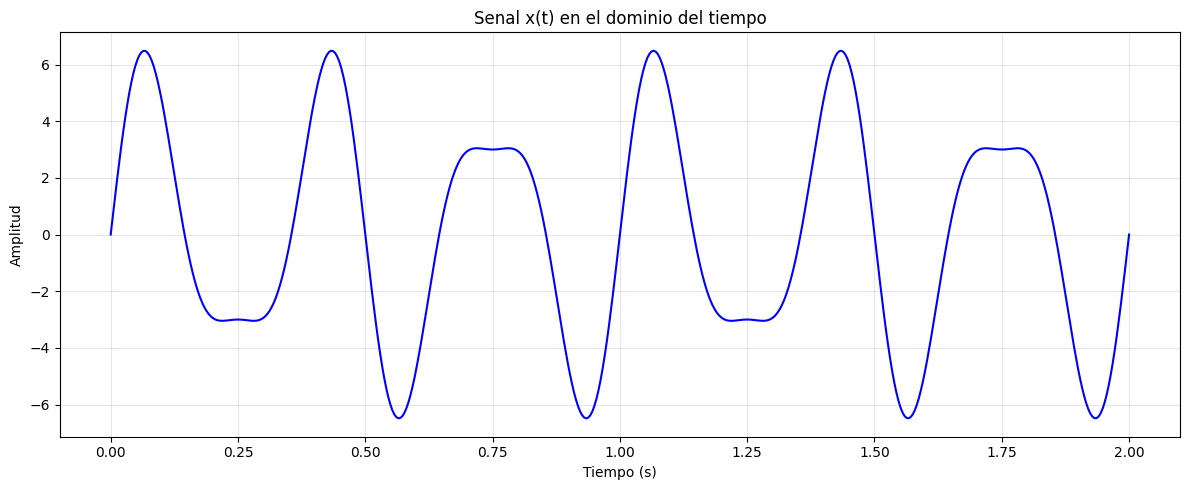

In [84]:
t = np.linspace(0, T, N)

x_t = 5 * np.sin(2 * pi * f1 * t) + 2 * np.sin(2 * pi * f2 * t)

plt.figure(figsize=(12, 5))
plt.plot(t, x_t, 'b-', linewidth=1.5)
plt.title('Senal x(t) en el dominio del tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

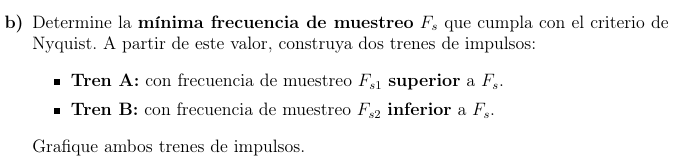

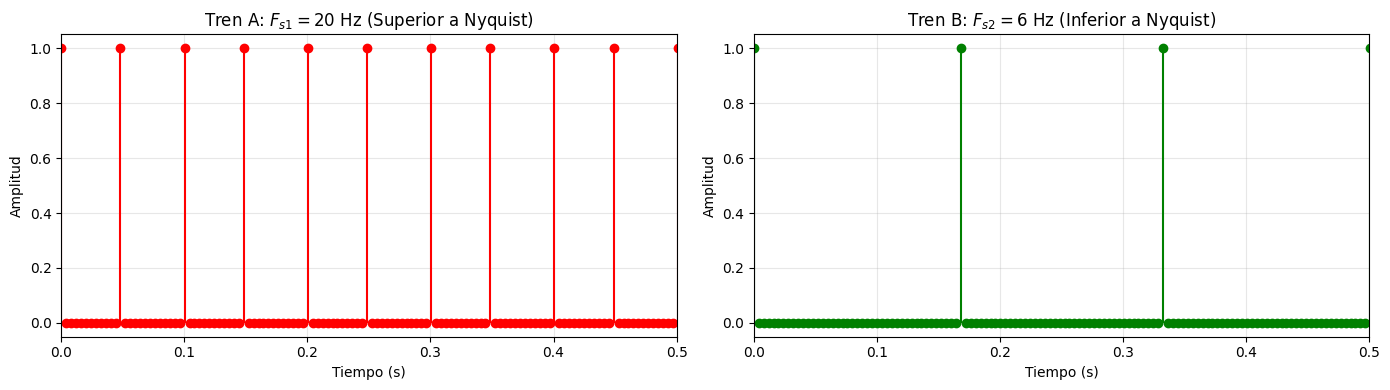

In [85]:
Fs1 = 20
Ts1 = 1 / Fs1
puntosA = np.arange(0, T, Ts1)

Fs2 = 6
Ts2 = 1 / Fs2
puntosB = np.arange(0, T, Ts2)

impulsoA = np.zeros_like(t)
impulsoB = np.zeros_like(t)

for ti in puntosA:
    idx = np.argmin(np.abs(t - ti))
    impulsoA[idx] = 1

for ti in puntosB:
    idx = np.argmin(np.abs(t - ti))
    impulsoB[idx] = 1

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.stem(t, impulsoA, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.title(f'Tren A: $F_{{s1}} = {Fs1}$ Hz (Superior a Nyquist)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.5)

plt.subplot(1, 2, 2)
plt.stem(t, impulsoB, linefmt='g-', markerfmt='go', basefmt=' ')
plt.title(f'Tren B: $F_{{s2}} = {Fs2}$ Hz (Inferior a Nyquist)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.5)

plt.tight_layout()
plt.show()

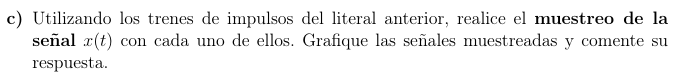

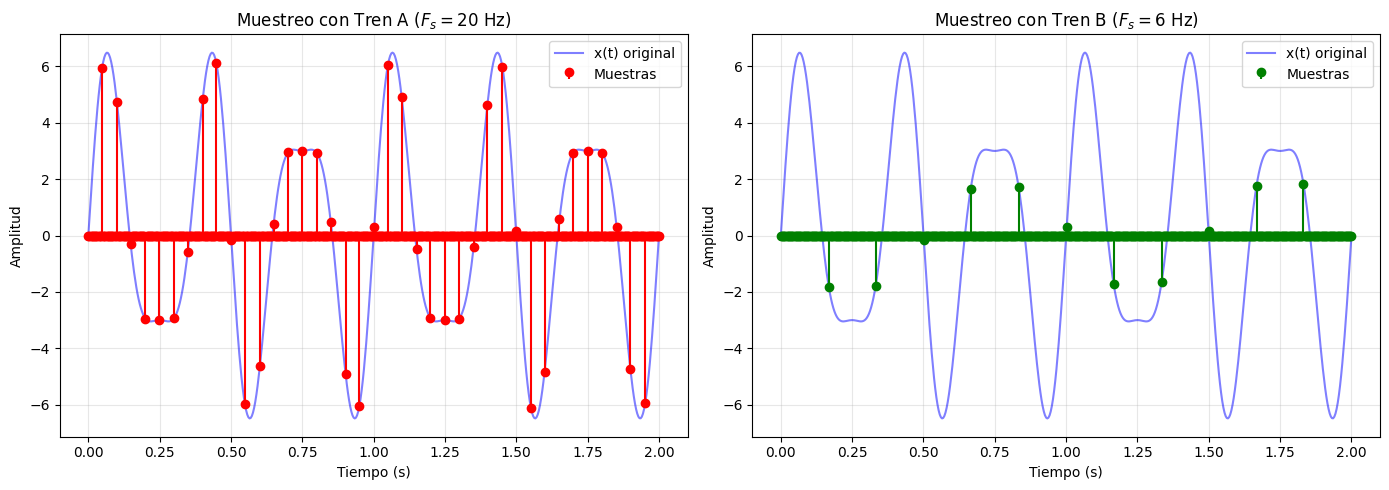

In [86]:
x_muestreada_A = x_t * impulsoA
x_muestreada_B = x_t * impulsoB

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x_t, 'b-', alpha=0.5, label='x(t) original')
plt.stem(t, x_muestreada_A, linefmt='r-', markerfmt='ro', basefmt=' ', label='Muestras')
plt.title(f'Muestreo con Tren A ($F_s = {Fs1}$ Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t, x_t, 'b-', alpha=0.5, label='x(t) original')
plt.stem(t, x_muestreada_B, linefmt='g-', markerfmt='go', basefmt=' ', label='Muestras')
plt.title(f'Muestreo con Tren B ($F_s = {Fs2}$ Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Con el tren A, se obtendrá una señal muestreada que representa fielmente la señal original, debido a que hay mayor frecuencia de muestreo. Con el tren B, se observa un fenómeno de aliasing ya que hay menos puntos de muestreo, por lo que la señal reconstruida no será parecida a la original.

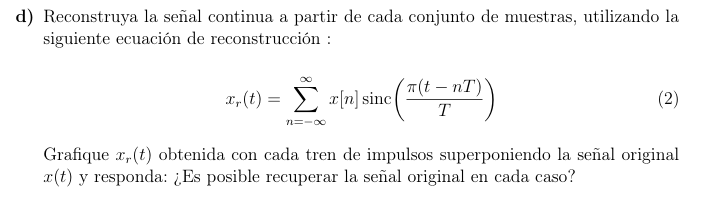

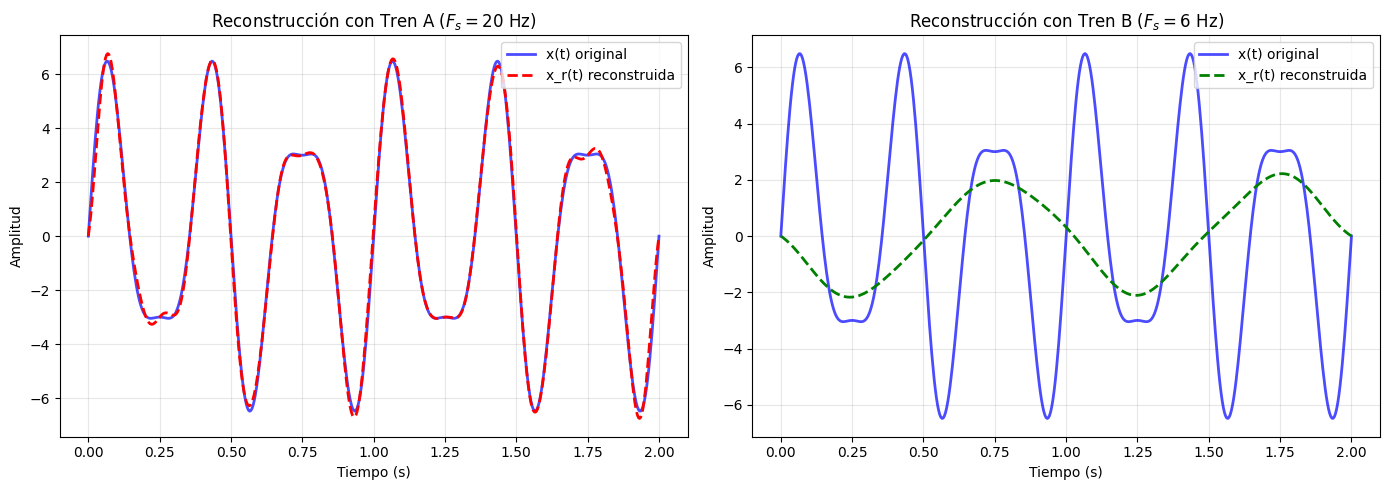

In [87]:
def sinc(x):
    """Funcion sinc normalizada: sin(pi*x)/(pi*x)"""
    x = np.asarray(x)
    result = np.ones_like(x)
    nocero = x != 0
    result[nocero] = np.sin(np.pi * x[nocero]) / (np.pi * x[nocero])
    return result

def reconstruir_senal(t, t_muestras, x_muestras, Ts):
    """Reconstruye la señal usando la fórmula de muestreo"""
    x_r = np.zeros_like(t)
    for i, ti in enumerate(t):
        n = (ti - t_muestras[0]) / Ts
        x_r[i] = np.sum(x_muestras * sinc(n - np.arange(len(x_muestras))))
    return x_r

idx_A = np.where(impulsoA > 0)[0]
idx_B = np.where(impulsoB > 0)[0]

t_muestras_A = t[idx_A]
x_muestras_A = x_t[idx_A]

t_muestras_B = t[idx_B]
x_muestras_B = x_t[idx_B]

x_r_A = reconstruir_senal(t, t_muestras_A, x_muestras_A, Ts1)
x_r_B = reconstruir_senal(t, t_muestras_B, x_muestras_B, Ts2)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x_t, 'b-', linewidth=2, label='x(t) original', alpha=0.7)
plt.plot(t, x_r_A, 'r--', linewidth=2, label='x_r(t) reconstruida')
plt.title(f'Reconstrucción con Tren A ($F_s = {Fs1}$ Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t, x_t, 'b-', linewidth=2, label='x(t) original', alpha=0.7)
plt.plot(t, x_r_B, 'g--', linewidth=2, label='x_r(t) reconstruida')
plt.title(f'Reconstrucción con Tren B ($F_s = {Fs2}$ Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se evidencia que con el Tren A (Fs = 20 Hz > Fs_min = 10 Hz) cumple con el criterio de Nyquist, la señal se reconstruye correctamente, por lo que casi no hay perdida de información.

En cambio, con el Tren B (Fs = 6 Hz < Fs_min = 10 Hz) no cumple con el criterio de Nyquist, por lo que ocurre ALIASING, lo que implica que la señal reconstruida es diferente a la original, se pierde información y no se puede recuperar.